Randomly Selected Stocks: {'Risk_Averse': 'ASIANPAINT.NS', 'Risk_Neutral': 'BHARTIARTL.NS', 'Risk_Seeking': 'BPCL.NS'}


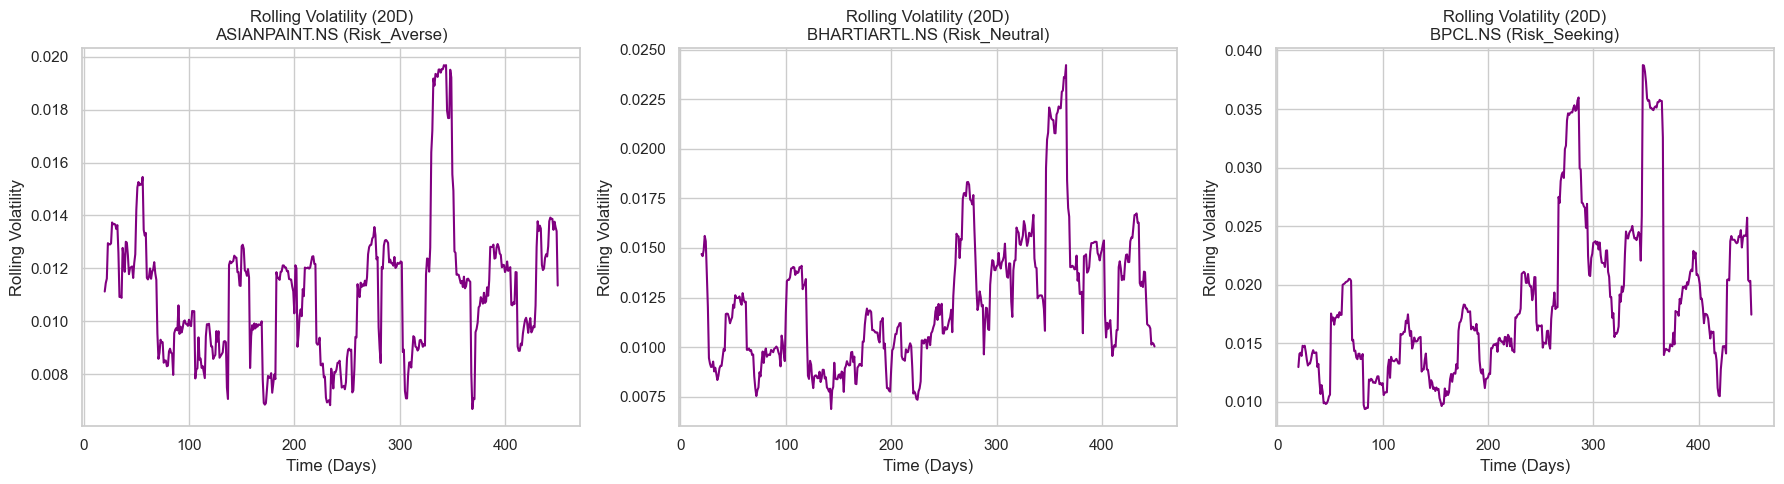

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

# --- Category files ---
category_files = {
    "Risk_Averse": "/Users/pranayvij/MTP-Work/categorized_results/risk_averse_stocks.csv",
    "Risk_Neutral": "/Users/pranayvij/MTP-Work/categorized_results/risk_neutral_stocks.csv",
    "Risk_Seeking": "/Users/pranayvij/MTP-Work/categorized_results/risk_seeking_stocks.csv"
}

# --- Path where your test stock CSVs are stored ---
base_path = "/Users/pranayvij/MTP-Work/test_data/"

# --- Randomly select 1 stock from each category ---
selected_stocks = {}

for category, file_path in category_files.items():
    df = pd.read_csv(file_path)
    ticker_list = df['Ticker'].tolist()
    chosen_stock = random.choice(ticker_list)
    selected_stocks[category] = chosen_stock

print("Randomly Selected Stocks:", selected_stocks)

# --- Plot Rolling Volatility for selected stocks ---
plt.figure(figsize=(18, 5))
sns.set_style("whitegrid")

for idx, (category, stock) in enumerate(selected_stocks.items(), 1):
    file_path = os.path.join(base_path, f"{stock}_test.csv")
    
    try:
        df = pd.read_csv(file_path)
        df['Return'] = df['Close'].pct_change()
        df['Rolling_Volatility'] = df['Return'].rolling(window=20).std()
        
        plt.subplot(1, 3, idx)
        plt.plot(df['Rolling_Volatility'], color='purple')
        plt.title(f"Rolling Volatility (20D)\n{stock} ({category})")
        plt.xlabel("Time (Days)")
        plt.ylabel("Rolling Volatility")
        plt.grid(True)
    
    except FileNotFoundError:
        print(f"⚠️ File not found for {stock}. Skipping...")

plt.tight_layout()
plt.show()


Randomly Selected Stocks: {'Risk_Averse': 'HDFCBANK.NS', 'Risk_Neutral': 'AMBUJACEM.NS', 'Risk_Seeking': 'INDUSINDBK.NS'}


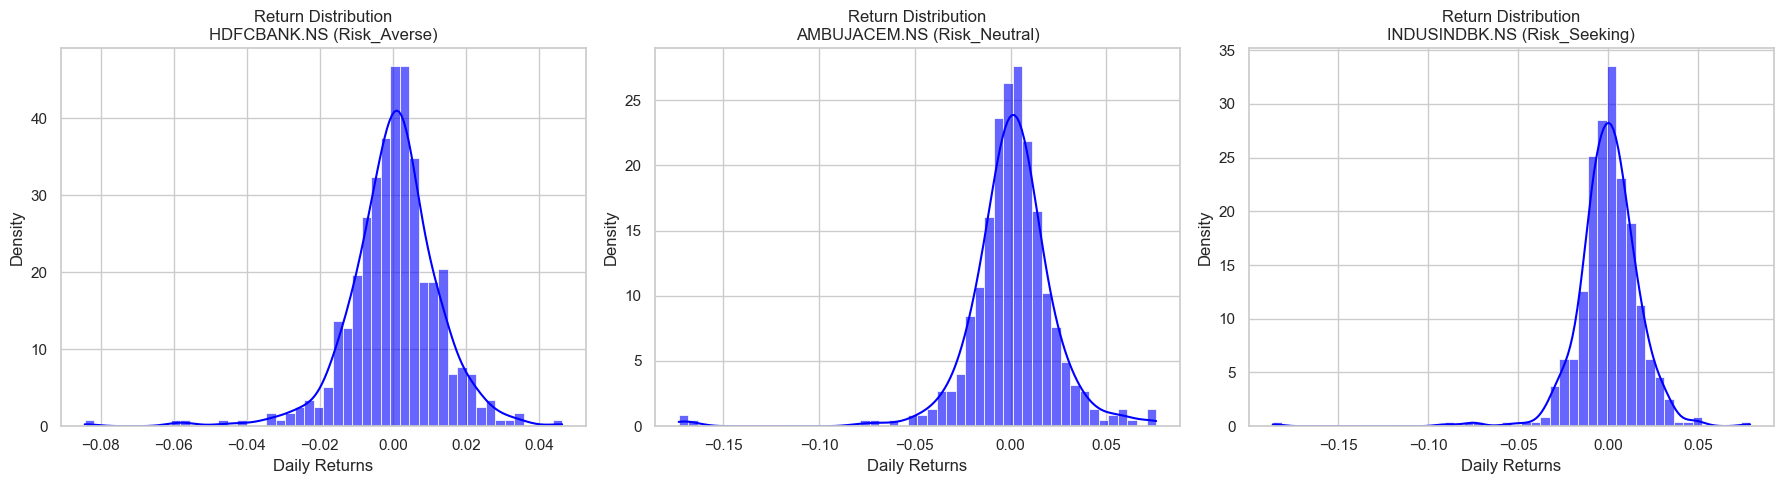

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

# --- Category files ---
category_files = {
    "Risk_Averse": "/Users/pranayvij/MTP-Work/categorized_results/risk_averse_stocks.csv",
    "Risk_Neutral": "/Users/pranayvij/MTP-Work/categorized_results/risk_neutral_stocks.csv",
    "Risk_Seeking": "/Users/pranayvij/MTP-Work/categorized_results/risk_seeking_stocks.csv"
}

# --- Path where your test stock CSVs are stored ---
base_path = "/Users/pranayvij/MTP-Work/test_data/"

# --- Randomly select 1 stock from each category ---
selected_stocks = {}

for category, file_path in category_files.items():
    df = pd.read_csv(file_path)
    ticker_list = df['Ticker'].tolist()
    chosen_stock = random.choice(ticker_list)
    selected_stocks[category] = chosen_stock

print("Randomly Selected Stocks:", selected_stocks)

# --- Plot Return Distributions for selected stocks ---
plt.figure(figsize=(18, 5))
sns.set_style("whitegrid")

for idx, (category, stock) in enumerate(selected_stocks.items(), 1):
    file_path = os.path.join(base_path, f"{stock}_test.csv")
    
    try:
        df = pd.read_csv(file_path)
        df['Return'] = df['Close'].pct_change()
        
        plt.subplot(1, 3, idx)
        sns.histplot(df['Return'].dropna(), kde=True, color='blue', bins=50, stat="density", alpha=0.6)
        plt.title(f"Return Distribution\n{stock} ({category})")
        plt.xlabel("Daily Returns")
        plt.ylabel("Density")
        plt.grid(True)
    
    except FileNotFoundError:
        print(f"⚠️ File not found for {stock}. Skipping...")

plt.tight_layout()
plt.show()
